# Histogram Equalization - Custom Implementation

Implement a custom histogram equalization function and apply it to the runway image.

**Algorithm:**
1. Calculate the histogram of the image
2. Compute the cumulative distribution function (CDF)
3. Normalize the CDF to the range [0, 255]
4. Map each pixel intensity to its equalized value using the normalized CDF

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set up matplotlib
plt.style.use('default')
%matplotlib inline


## Custom Histogram Equalization Function

In [3]:
def histogram_equalization(image):
    
    # Step 1: Calculate histogram
    # Count frequency of each intensity value (0-255)
    histogram = np.zeros(256, dtype=int)
    for intensity in range(256):
        histogram[intensity] = np.sum(image == intensity)
    
    # Step 2: Calculate cumulative distribution function (CDF)
    cdf = np.zeros(256, dtype=int)
    cdf[0] = histogram[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + histogram[i]
    
    # Step 3: Normalize CDF to range [0, 255]
    cdf_min = cdf[cdf > 0].min()
    total_pixels = image.shape[0] * image.shape[1]
    
    cdf_normalized = ((cdf - cdf_min) / (total_pixels - cdf_min) * 255).astype(np.uint8)
    
    # Step 4: Map each pixel to its equalized value
    equalized_image = cdf_normalized[image]
    
    return equalized_image, histogram, cdf, cdf_normalized

print("Custom histogram equalization function defined successfully!")


Custom histogram equalization function defined successfully!


## Load and Display Original Runway Image

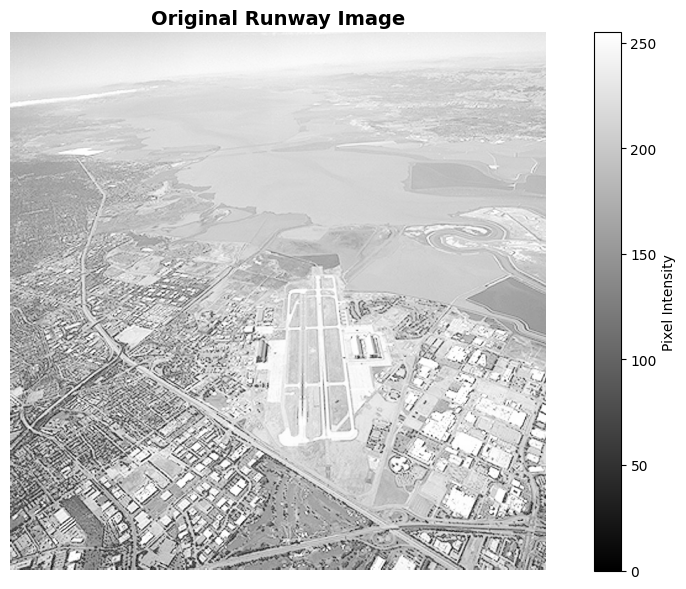

Image shape: (769, 765)
Data type: uint8
Intensity range: [0, 255]
Mean intensity: 197.12
Standard deviation: 40.88


In [4]:
# Load the runway image in grayscale
img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("runway.png not found. Please ensure the file exists.")

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Runway Image', fontsize=14, fontweight='bold')
plt.colorbar(label='Pixel Intensity')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {img.shape}")
print(f"Data type: {img.dtype}")
print(f"Intensity range: [{img.min()}, {img.max()}]")
print(f"Mean intensity: {img.mean():.2f}")
print(f"Standard deviation: {img.std():.2f}")


## Apply Custom Histogram Equalization

In [5]:
# Apply custom histogram equalization
img_equalized, hist_original, cdf_original, cdf_normalized = histogram_equalization(img)

print("Histogram equalization completed!")
print(f"Equalized image shape: {img_equalized.shape}")
print(f"Equalized intensity range: [{img_equalized.min()}, {img_equalized.max()}]")
print(f"Equalized mean intensity: {img_equalized.mean():.2f}")
print(f"Equalized standard deviation: {img_equalized.std():.2f}")


Histogram equalization completed!
Equalized image shape: (769, 765)
Equalized intensity range: [0, 255]
Equalized mean intensity: 128.17
Equalized standard deviation: 73.99


## Compare Original and Equalized Images

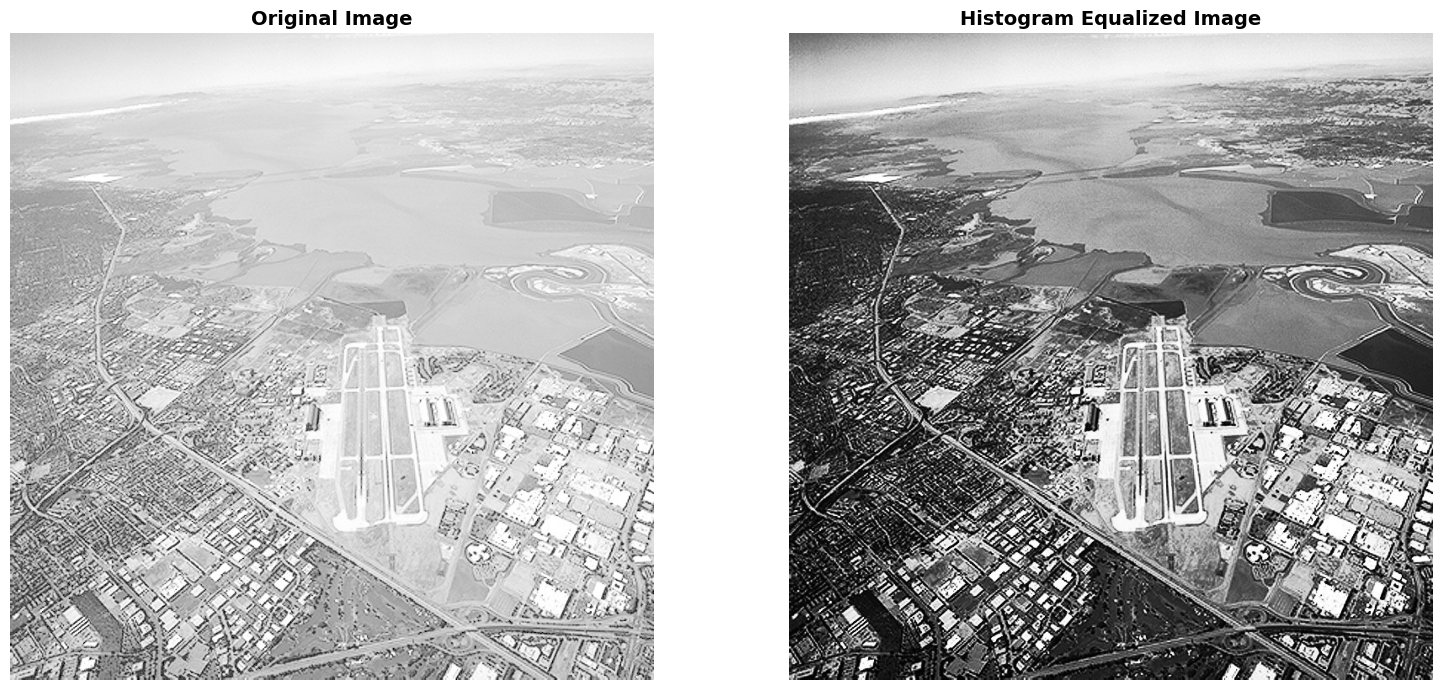

Notice the improved contrast in the equalized image!


In [6]:
# Display original and equalized images side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_equalized, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Histogram Equalized Image', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Notice the improved contrast in the equalized image!")
